# Part 1: Data Preprocessing & Feature Engineering 

In [2]:
%pip install pandas polars pyarrow numpy matplotlib seaborn torch scikit-learn pathlib tensorflow 

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.5/223.5 MB 29.7 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 29.1 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 27.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 20.0 MB/s  0:00:00
Using cached requests-2.32.5-py3-none-any.whl (64 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 30.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Data Download and Schema Overview

In [3]:
import polars as pl
import pathlib as pathlb
from sklearn.preprocessing import StandardScaler, OneHotEncoder

file_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
base_dir = pathlb.Path('data/raw')
file_name = 'yellow_tripdata_2024-01.parquet'
file_path = base_dir/file_name

## Checks if file downloaded if not it downloads it
if not file_path.is_file() :
    base_dir.mkdir(parents=True, exist_ok=True)
    print(f" Error {file_name} not found downloading...\n")
    pl.read_parquet(file_url).write_parquet(file_path)
taxi_df = pl.read_parquet(file_path)

print(f"{"SCHEMA"}\n")
print(f"{"Name":<25}Type")
for col, type in taxi_df.schema.items() :
    print(f"{col:<25}{type}")


taxi_df.head()

SCHEMA

Name                     Type
VendorID                 Int32
tpep_pickup_datetime     Datetime(time_unit='ns', time_zone=None)
tpep_dropoff_datetime    Datetime(time_unit='ns', time_zone=None)
passenger_count          Int64
trip_distance            Float64
RatecodeID               Int64
store_and_fwd_flag       String
PULocationID             Int32
DOLocationID             Int32
payment_type             Int64
fare_amount              Float64
extra                    Float64
mta_tax                  Float64
tip_amount               Float64
tolls_amount             Float64
improvement_surcharge    Float64
total_amount             Float64
congestion_surcharge     Float64
Airport_fee              Float64


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,"""N""",186,79,2,17.7,1.0,0.5,0.0,0.0,1.0,22.7,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0


In [4]:
cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime','trip_distance','PULocationID', 'DOLocationID','fare_amount','tip_amount','payment_type']

try:
    # taxi_df should already be defined as a Polars DataFrame
    missing_cols = set(cols) - set(taxi_df.columns)

    if missing_cols:
        print("Missing columns:", missing_cols)
    else:
        print("No missing columns.")
except Exception as e:
    print("Error while checking columns:", e)

No missing columns.


Injesting Lookup file

In [5]:
file_name ='lookup.csv'
file_path = base_dir / file_name
file_url = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'

if not file_path.is_file():
    base_dir.mkdir(parents=True, exist_ok=True)
    print(f" Error {file_name} not found downloading...\n")
    pl.read_csv(file_url,encoding="utf8-lossy").write_csv(file_path)

lookup_df = pl.read_csv(file_path)

## Data Cleaning


### Cleaning Taxi Parquet

In [6]:
initial_rows = len(taxi_df)

# --- STEP 1: Nulls and NaNs ---
# We calculate null_rows by checking how many rows fail the 'is_not_null' check
null_rows = initial_rows - taxi_df.filter(pl.all_horizontal(pl.col(cols).is_not_null())).height

# Apply the filter for both Nulls and NaNs
taxi_df = taxi_df.filter(
    pl.all_horizontal(pl.col(cols).is_not_null()) &
    (~pl.col("fare_amount").is_nan()) & 
    (~pl.col("trip_distance").is_nan())
)
# nan_rows is what's left after accounting for nulls
nan_rows = initial_rows - len(taxi_df) - null_rows

# --- STEP 2: Distance ---
pre_dist_count = len(taxi_df)
taxi_df = taxi_df.filter(pl.col('trip_distance') > 0)
distance_rows = pre_dist_count - len(taxi_df)

# --- STEP 3: Fare ---
pre_fare_count = len(taxi_df)
taxi_df = taxi_df.filter((pl.col('fare_amount') > 0) & (pl.col('fare_amount') <= 500))
fare_rows = pre_fare_count - len(taxi_df)

# --- STEP 4: Time Duration ---
pre_time_count = len(taxi_df)
taxi_df = taxi_df.filter(pl.col('tpep_dropoff_datetime') > pl.col('tpep_pickup_datetime'))
time_rows = pre_time_count - len(taxi_df)

# --- STEP 5: Year/Date Range ---
pre_year_count = len(taxi_df)
taxi_df = taxi_df.filter(pl.col('tpep_pickup_datetime').dt.year() == 2024)
year_rows = pre_year_count - len(taxi_df)

removed_rows = initial_rows - len(taxi_df)


## Feature Engineering


### Joining Boroughs to Taxi Data Frame

In [7]:
# 1. Join for Pickup Location
taxi_df = taxi_df.join(
    lookup_df.select(["LocationID", "Borough"]),
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
).rename({"Borough": "PU_Borough"})

# 2. Join for Dropoff Location
taxi_df = taxi_df.join(
    lookup_df.select(["LocationID", "Borough"]),
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
).rename({"Borough": "DO_Borough"})

# 3. FIXED: Use the exact names from the rename calls above
taxi_df = taxi_df.with_columns([
    pl.col("PU_Borough").fill_null("Unknown"),
    pl.col("DO_Borough").fill_null("Unknown")
])

print("Join successful and nulls filled for PU_Borough and DO_Borough.")

Join successful and nulls filled for PU_Borough and DO_Borough.


In [8]:
#Temporal features
taxi_df = taxi_df.with_columns( 
    #Create col that indexes pickup hour
    (pl.col('tpep_pickup_datetime').dt.hour().alias('pickup_hour')),
    #Create col that indexes weekday, starting at 0
    (pl.col('tpep_pickup_datetime').dt.weekday()-1).alias('pickup_day_of_week')
    ).with_columns(
        # Creates boolean weekend col
        (pl.col('pickup_day_of_week') >= 5).alias('is_weekend')
        .cast(pl.Int8)
    )
#Trip Features
taxi_df  = taxi_df.with_columns(
    (pl.col('tpep_dropoff_datetime')- pl.col('tpep_pickup_datetime'))
    #Convert trip duration minutes distance to interger
    .dt.total_minutes().alias('trip_duration_minutes')
    ).with_columns(
        #accounts for zero denominator error
        pl.when(pl.col('trip_duration_minutes') > 0)
        .then(pl.col('trip_distance')* 60/(pl.col('trip_duration_minutes')))
        .otherwise(0) #if duration 0 -> just 0 mph
        .alias('trip_speed_mph')
    )
taxi_df = taxi_df.with_columns(
    pl.col('trip_distance').log1p().alias('log_trip_distance'))
#Fare Features
taxi_df = taxi_df.with_columns(
        pl.when(pl.col('trip_distance') > 0)
        .then(pl.col('fare_amount')/(pl.col('trip_distance')))
        .otherwise(0) #if distance 0 -> just 0
        .alias('fare_per_mile'),
        pl.when(pl.col('trip_duration_minutes') > 0)
        .then(pl.col('fare_amount')/(pl.col('trip_duration_minutes')))
        .otherwise(0) #if distance 0 -> just 0
        .alias('fare_per_minute')
        )
taxi_df.head()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,PU_Borough,DO_Borough,pickup_hour,pickup_day_of_week,is_weekend,trip_duration_minutes,trip_speed_mph,log_trip_distance,fare_per_mile,fare_per_minute
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,i8,i8,i8,i64,f64,f64,f64,f64
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,"""N""",186,79,2,17.7,1.0,0.5,0.0,0.0,1.0,22.7,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,19,5.431579,1.000632,10.290698,0.931579
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,6,18.0,1.029619,5.555556,1.666667
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,17,16.588235,1.740466,4.957447,1.370588
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,8,10.5,0.875469,7.142857,1.25
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,6,8.0,0.587787,9.875,1.316667


In [9]:
# Filter for Credit Card (payment_type == 1)
taxi_df = taxi_df.filter(pl.col("payment_type") == 1)

# Print the shape to see how many rows are left
print(f"Rows after Credit Card filter {len(taxi_df)}")

Rows after Credit Card filter 2298339


In [10]:
taxi_df = taxi_df.with_columns([
    pl.col("tip_amount").cast(pl.Float64).alias("tip_amount"),
    
    (pl.col("tip_amount") > (pl.col("fare_amount") * 0.20))
    #casts the boolean value to 1 or zero
    .cast(pl.Int8)
    .alias("high_tip")
])

#display()
taxi_df.group_by("high_tip").agg(pl.len().alias("count")).with_columns(proportions = pl.col("count") / pl.col("count").sum())

high_tip,count,proportions
i8,u32,f64
0,553149,0.240673
1,1745190,0.759327


In [11]:
taxi_df.head()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,PU_Borough,DO_Borough,pickup_hour,pickup_day_of_week,is_weekend,trip_duration_minutes,trip_speed_mph,log_trip_distance,fare_per_mile,fare_per_minute,high_tip
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,i8,i8,i8,i64,f64,f64,f64,f64,i8
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,6,18.0,1.029619,5.555556,1.666667,1
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,17,16.588235,1.740466,4.957447,1.370588,0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,8,10.5,0.875469,7.142857,1.25,0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,6,8.0,0.587787,9.875,1.316667,1
1,2024-01-01 00:54:08,2024-01-01 01:26:31,1,4.7,1,"""N""",148,141,1,29.6,3.5,0.5,6.9,0.0,1.0,41.5,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,32,8.8125,1.740466,6.297872,0.925,1


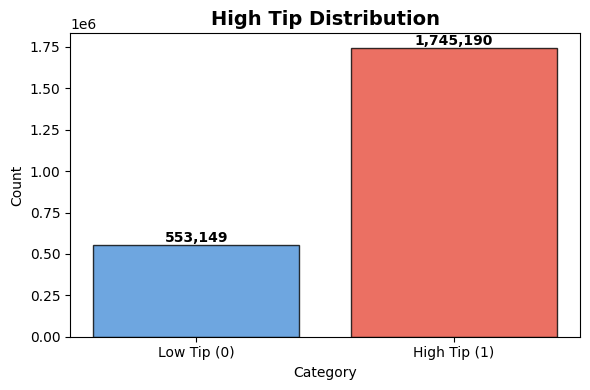

In [12]:
import matplotlib.pyplot as plt

# 1. Prepare the data using group_by (compatible with all Polars versions)
counts_df = (
    taxi_df.group_by("high_tip")
    .agg(pl.len().alias("count"))
    .sort("high_tip")
)

# 2. Extract the values for plotting
categories = ["Low Tip (0)", "High Tip (1)"]
counts = counts_df["count"].to_list()

# 3. Create the plot
fig, ax = plt.subplots(figsize=(6, 4))

# We use ax.bar instead of the pandas-style .plot(kind='bar')
bars = ax.bar(categories, counts, color=['#4A90D9', '#E74C3C'], edgecolor='black', alpha=0.8)

# Formatting
ax.set_title('High Tip Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Count')

# 4. Add the text labels on top of the bars
for i, count in enumerate(counts):
    ax.text(i, count + (max(counts) * 0.01), f'{count:,}', 
            ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [13]:
import polars as pl

# 1. Grab numeric columns (Integers and Floats)
numeric_features = [
    col for col, dtype in taxi_df.schema.items() 
    if dtype.is_numeric()
]

# 2. Grab categorical columns (Strings/Objects)
# Note: Polars uses 'String' instead of 'object'
categorical_features = [
    col for col, dtype in taxi_df.schema.items() 
    if dtype == pl.String
]

# 3. Remove your targets so you don't "leak" the answer to the model
if 'tip_amount' in numeric_features: numeric_features.remove('tip_amount')
if 'high_tip' in numeric_features: numeric_features.remove('high_tip')
if "PULocationID" in numeric_features: numeric_features.remove("PULocationID")
if "DOLocationID" in numeric_features: numeric_features.remove("DOLocationID")
if "total_amount" in numeric_features: numeric_features.remove("total_amount")
#if "fare_amount" in numeric_features: numeric_features.remove("fare_amount")
#if "tolls_amount" in numeric_features: numeric_features.remove("tolls_amount")
#if "mta_tax" in numeric_features: numeric_features.remove("mta_tax")
# (Remove 'income' or whatever your specific target name is here)

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")



Numeric features (20): ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
Categorical features (3): ['store_and_fwd_flag', 'PU_Borough', 'DO_Borough']


In [14]:
import polars as pl

# 1. Replace '?' with None (Polars' NaN equivalent) across all string columns
# Then cast numeric-looking strings back to numbers if necessary
taxi_df = taxi_df.with_columns(
    pl.all().map_batches(lambda s: s.replace("?", None) if s.dtype == pl.String else s)
)

# 2. Calculate Missing Value Percentages
total_rows = len(taxi_df)
missing_stats = (
    taxi_df.select([
        (pl.col(c).is_null().sum() / total_rows * 100).round(2).alias(c)
        for c in taxi_df.columns
    ])
    .melt(variable_name="column", value_name="missing_pct")
    .filter(pl.col("missing_pct") > 0)
)


# 3. FIXED: Calculate rows with at least one null (Total affected)
# any_horizontal returns True if AT LEAST ONE column in that row is null
total_affected = taxi_df.filter(pl.any_horizontal(pl.all().is_null())).height

# 4. Define the columns you want to check for your cleaning step later
# (Used for your 'cols' variable in the cleaning summary)
cols = taxi_df.columns 

print("Missing value percentages:")
print(missing_stats)
print(f"\nTotal rows affected: {total_affected:,} ({(total_affected/total_rows*100):.1f}%)")

Missing value percentages:
shape: (0, 2)
┌────────┬─────────────┐
│ column ┆ missing_pct │
│ ---    ┆ ---         │
│ str    ┆ f64         │
╞════════╪═════════════╡
└────────┴─────────────┘

Total rows affected: 0 (0.0%)


/var/folders/yd/xx3gc_bd0y911x26fq021tgw0000gn/T/ipykernel_48834/3675321585.py:16: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="column", value_name="missing_pct")


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# 1. Numeric pipeline: Median handles outliers better than Mean (Stats Exam win!)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Categorical pipeline: Standard for handling strings
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

print('Numeric transformer steps:', [step[0] for step in numeric_transformer.steps])
print('Categorical transformer steps:', [step[0] for step in categorical_transformer.steps])
from sklearn.compose import ColumnTransformer

# 3. Combine into a preprocessor
# We tell it: use numeric_transformer for numeric_features, 
# and categorical_transformer for categorical_features.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Drops any columns we didn't explicitly include (like targets)
)

print("Preprocessor successfully defined!")

Numeric transformer steps: ['imputer', 'scaler']
Categorical transformer steps: ['imputer', 'onehot']
Preprocessor successfully defined!


In [16]:
from sklearn.compose import ColumnTransformer

# Initialize the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print('ColumnTransformer configured:')
print(f'  Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'  Categorical features ({len(categorical_features)}): {categorical_features}')

ColumnTransformer configured:
  Numeric features (20): ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
  Categorical features (3): ['store_and_fwd_flag', 'PU_Borough', 'DO_Borough']


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create full pipeline: preprocessing + model
# We use max_iter=1000 to ensure the solver has enough iterations to converge
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

print('Full Pipeline:')
print(pipeline)

Full Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['VendorID',
                                                   'passenger_count',
                                                   'trip_distance',
                                                   'RatecodeID', 'payment_type',
                                                   'fare_amount', 'extra',
                                                   'mta_tax', 'tolls_amount',
                                                   'improvement_surcharge',
                                       

In [18]:
from sklearn.model_selection import train_test_split
import polars as pl
import numpy as np

# 1. Define Features and Target
# We use the corrected feature lists we discussed
X = taxi_df.select(numeric_features + categorical_features)
y = taxi_df.select("high_tip").to_series().to_numpy()

# 2. First Split: 70% Training, 30% Temporary (for Val/Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

# 3. Second Split: Divide the 30% temporary set exactly in half (15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp
)

# 4. Apply Preprocessing (Requirement b)
# CRITICAL: We fit_transform the training data, then ONLY transform val/test.
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

# 5. Documentation Summary (Requirement c & d)
def get_dist(labels):
    counts = np.bincount(labels.astype(int))
    low = counts[0] if len(counts) > 0 else 0
    high = counts[1] if len(counts) > 1 else 0
    return f"{low:,} Low / {high:,} High ({(high/len(labels))*100:.2f}% High)"

print("--- Data Split & Stratification Summary ---")
print(f"{'Split Set':<15} | {'Row Count':<10} | {'Class Distribution (Target: high_tip)'}")
print("-" * 75)
print(f"{'Training':<15} | {len(y_train):<10,} | {get_dist(y_train)}")
print(f"{'Validation':<15} | {len(y_val):<10,} | {get_dist(y_val)}")
print(f"{'Testing':<15} | {len(y_test):<10,} | {get_dist(y_test)}")

print("\n--- Feature Transformation Summary ---")
print(f"Total Features Processed: {X_train_transformed.shape[1]}")
print(f"Numeric Features Scaled: {len(numeric_features)}")
print(f"Categorical Features Encoded: {len(categorical_features)}")

--- Data Split & Stratification Summary ---
Split Set       | Row Count  | Class Distribution (Target: high_tip)
---------------------------------------------------------------------------
Training        | 1,608,837  | 387,204 Low / 1,221,633 High (75.93% High)
Validation      | 344,751    | 82,972 Low / 261,779 High (75.93% High)
Testing         | 344,751    | 82,973 Low / 261,778 High (75.93% High)

--- Feature Transformation Summary ---
Total Features Processed: 38
Numeric Features Scaled: 20
Categorical Features Encoded: 3


___

In [19]:
# 1. Identify the types after transformation
# (StandardScaler keeps numeric count; One-Hot expands categorical)
all_input_cols = set(taxi_df.columns)
modeled_cols = set(numeric_features + categorical_features)
excluded_cols = all_input_cols - modeled_cols - {'high_tip'}

print("===============================================================")
print("                  FEATURE MODELING SUMMARY                     ")
print("===============================================================")

print(f"\n[NUMERIC FEATURES] - Total: {len(numeric_features)}")
print(f"Columns: {numeric_features}")
print("Processing: Median Imputation + Standardization (Z-score scaling)")

print(f"\n[CATEGORICAL FEATURES] - Total: {len(categorical_features)}")
print(f"Columns: {categorical_features}")
print("Processing: Most Frequent Imputation + One-Hot Encoding")

print(f"\n[EXCLUDED FEATURES] - Total: {len(excluded_cols)}")
print("-" * 30)

for col in sorted(excluded_cols):
    reason = ""
    if col in ['total_amount', 'fare_amount', 'tip_amount']:
        reason = "Target Leakage: Directly contains or calculates the dependent variable."
    elif 'datetime' in col:
        reason = "Non-numeric: Raw timestamps cannot be used in Logistic Regression without extraction."
    elif col in ['PULocationID', 'DOLocationID']:
        reason = "Redundancy: Replaced by higher-level 'Borough' features to reduce dimensionality."
    else:
        reason = "High Cardinality or Uninformative for this specific model."
    
    print(f"• {col:<22} | {reason}")

print("===============================================================")

                  FEATURE MODELING SUMMARY                     

[NUMERIC FEATURES] - Total: 20
Columns: ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
Processing: Median Imputation + Standardization (Z-score scaling)

[CATEGORICAL FEATURES] - Total: 3
Columns: ['store_and_fwd_flag', 'PU_Borough', 'DO_Borough']
Processing: Most Frequent Imputation + One-Hot Encoding

[EXCLUDED FEATURES] - Total: 6
------------------------------
• DOLocationID           | Redundancy: Replaced by higher-level 'Borough' features to reduce dimensionality.
• PULocationID           | Redundancy: Replaced by higher-level 'Borough' features to reduce dimensionality.
• tip_amount             | Target Leakage: Directly 

In [20]:
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. PREPARE THE DATA (UNIFIED SPLIT)
# We split X and y together using the same random_state to keep them aligned
# 'X' should be your feature set (excluding tip_amount, total_amount, etc.)
y_reg = taxi_df.select("tip_amount").to_series().to_numpy()

X_train, X_temp, y_train_reg, y_temp_reg = train_test_split(
    X, y_reg, 
    test_size=0.30, 
    random_state=42
)

X_val, X_test, y_val_reg, y_test_reg = train_test_split(
    X_temp, y_temp_reg, 
    test_size=0.50, 
    random_state=42
)

# 2. DEFINE THE MODELS
lr_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

rf_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

# 3. TRAIN WITH TIMERS
print("Training Baseline Models...")
start_lr = time.time()
lr_reg.fit(X_train, y_train_reg)
lr_time = time.time() - start_lr

start_rf = time.time()
rf_reg.fit(X_train, y_train_reg)
rf_time = time.time() - start_rf

# 4. EVALUATION FUNCTION
def get_regression_metrics(model, X, y_true, name, duration):
    preds = model.predict(X)
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)
    return {
        "Model": name,
        "MAE": f"{mae:.4f}",
        "RMSE": f"{rmse:.4f}",
        "R^2": f"{r2:.4f}",
        "Time (s)": f"{duration:.2f}s"
    }

# 5. GENERATE THE RESULTS TABLE
lr_stats = get_regression_metrics(lr_reg, X_val, y_val_reg, "Linear Regression", lr_time)
rf_stats = get_regression_metrics(rf_reg, X_val, y_val_reg, "Random Forest", rf_time)

results_df = pd.DataFrame([lr_stats, rf_stats])
print("\n--- Final Baseline Regression Performance ---")
print(results_df.to_string(index=False))

Training Baseline Models...

--- Final Baseline Regression Performance ---
            Model    MAE   RMSE    R^2 Time (s)
Linear Regression 1.2066 2.3311 0.6308    6.27s
    Random Forest 1.1834 2.3051 0.6390  182.76s


____


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. PREPARE THE BINARY TARGET
y_clf = taxi_df.select("high_tip").to_series().to_numpy()

# Split X and y_clf together
X_train, X_temp, y_train_clf, y_temp_clf = train_test_split(
    X, y_clf, test_size=0.30, random_state=42
)
X_val, X_test, y_val_clf, y_test_clf = train_test_split(
    X_temp, y_temp_clf, test_size=0.50, random_state=42
)

# 2. DEFINE CLASSIFICATION PIPELINES
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

rf_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

# 3. TRAIN
print("Training Classification Models...")
log_reg.fit(X_train, y_train_clf)
rf_clf.fit(X_train, y_train_clf)

# 4. EVALUATION FUNCTION
def get_classification_metrics(model, X, y_true, name):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1] # Needed for AUC-ROC
    
    return {
        "Model": name,
        "Accuracy": f"{accuracy_score(y_true, preds):.4f}",
        "Precision": f"{precision_score(y_true, preds):.4f}",
        "Recall": f"{recall_score(y_true, preds):.4f}",
        "F1-Score": f"{f1_score(y_true, preds):.4f}",
        "AUC-ROC": f"{roc_auc_score(y_true, probs):.4f}"
    }

# 5. RESULTS TABLE
log_stats = get_classification_metrics(log_reg, X_val, y_val_clf, "Logistic Regression")
rf_stats = get_classification_metrics(rf_clf, X_val, y_val_clf, "Random Forest Classifier")

results_clf_df = pd.DataFrame([log_stats, rf_stats])
print("\n--- Baseline Classification: Validation Set Performance ---")
print(results_clf_df.to_string(index=False))

Training Classification Models...

--- Baseline Classification: Validation Set Performance ---
                   Model Accuracy Precision Recall F1-Score AUC-ROC
     Logistic Regression   0.7719    0.7700 0.9979   0.8693  0.6090
Random Forest Classifier   0.7722    0.7697 0.9994   0.8696  0.6189


In [22]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Define the parameter space
# Note the 'regressor__' prefix to point to the Random Forest in your pipeline
param_dist = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [10, 20, 30, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__bootstrap': [True, False]
}

# 2. Set up the Randomized Search
# n_iter=10 means it will pick 10 random combinations to try
# cv=3 means it will do 3-fold cross-validation
random_search = RandomizedSearchCV(
    estimator=rf_reg, 
    param_distributions=param_dist, 
    n_iter=20, 
    cv=3, 
    verbose=2, 
    random_state=42, 
    n_jobs=-1
)

# 3. Run the search
print("Searching for best hyperparameters...")
start_time = time.time()
random_search.fit(X_train, y_train_reg)
print(f"Search completed in {(time.time() - start_time):.2f}s")

# 4. See the best results
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best R² Score: {random_search.best_score_:.4f}")

Searching for best hyperparameters...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


KeyboardInterrupt: 

In [30]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split

# 1. CREATE A REPRESENTATIVE SAMPLE (The "Life Saver" step)
# We take 10% of the training data. This is statistically enough to find good params.
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, 
    y_train_reg, 
    train_size=0.25,   # Use 10% of data. If it's still slow, change to 0.05
    random_state=42
)

# 2. Define the parameter space
param_dist = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [10, 20, 30], # Removed 'None' to prevent infinite growth
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__bootstrap': [True] # True is generally better/faster for large data
}

# 3. Set up the Randomized Search
# n_iter=10 is plenty for a baseline search!
random_search = RandomizedSearchCV(
    estimator=rf_reg, 
    param_distributions=param_dist, 
    n_iter=20, # Reduced from 20 to 10 for speed
    cv=3, 
    verbose=2, 
    random_state=42, 
    n_jobs=-1 # Uses all CPU cores
)

# 4. Run the search on the SAMPLE
print(f"Searching for best hyperparameters using a 25% sample ({len(X_train_sample)} rows)...")
start_time = time.time()
random_search.fit(X_train_sample, y_train_sample)
print(f"Search completed in {(time.time() - start_time)/60:.2f} minutes")

# 5. See the best results
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_val)

# 2. Calculate final regression metrics
mae = mean_absolute_error(y_val_reg, y_pred)
rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred))
r2 = r2_score(y_val_reg, y_pred)

# 3. PRINT THE FINAL COMPARISON REPORT
print("\n" + "="*50)
print("   FINAL OPTIMIZED MODEL SUMMARY")
print("="*50)
print(f"Best Hyperparameters Found:")
for param, value in random_search.best_params_.items():
    print(f"  - {param.split('__')[1]}: {value}")

print("-" * 30)
print(f"Performance Metrics (Validation Set):")
print(f"  - R² Score:  {r2:.4f}")
print(f"  - MAE:       ${mae:.2f}")
print(f"  - RMSE:      ${rmse:.2f}")
print("="*50)

# 6. (Optional) Final Fit with Best Params
# Once you have the best params, you can use them to train on 100% of data 
# just once, which is much faster than doing 60 fits.
best_rf_model = random_search.best_estimator_

Searching for best hyperparameters using a 25% sample (402209 rows)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=2, regressor__n_estimators=50; total time= 2.2min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=2, regressor__n_estimators=50; total time= 2.3min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=100; total time= 3.9min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=100; total time= 4.0min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=100; total time= 4.0min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=2, regressor__n_estimators=50; total time= 2.3min
[CV] END regressor__boots

/Users/august/Developer/COMP3610A2/.conda/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=10, regressor__n_estimators=200; total time= 8.3min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=10, regressor__n_estimators=200; total time= 8.5min
[CV] END regressor__bootstrap=True, regressor__max_depth=20, regressor__min_samples_split=5, regressor__n_estimators=50; total time= 2.2min
[CV] END regressor__bootstrap=True, regressor__max_depth=30, regressor__min_samples_split=10, regressor__n_estimators=50; total time= 2.5min
[CV] END regressor__bootstrap=True, regressor__max_depth=30, regressor__min_samples_split=10, regressor__n_estimators=50; total time= 2.6min
[CV] END regressor__bootstrap=True, regressor__max_depth=30, regressor__min_samples_split=10, regressor__n_estimators=50; total time= 2.5min
[CV] END regressor__bootstrap=True, regressor__max_depth=10, regressor__min_samples_split=2, regressor__n_estimators=100; total time= 2.8min
[CV] END reg

In [32]:
print(random_search.best_params_.items())


dict_items([('regressor__n_estimators', 200), ('regressor__min_samples_split', 10), ('regressor__max_depth', 10), ('regressor__bootstrap', True)])


In [34]:
from sklearn.model_selection import cross_val_score

# 1. Use the ALREADY TUNED pipeline from your search
# This includes the preprocessor AND the best RF params (depth=10, estimators=200)
final_pipeline = random_search.best_estimator_

# 2. Run the 5-fold CV
print("Running official 5-fold Cross-Validation with the Pipeline...")
cv_scores = cross_val_score(
    final_pipeline, 
    X_train_sample, 
    y_train_sample, 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)

print(f"\n--- 5-Fold CV Results ---")
print(f"Individual Scores: {cv_scores}")
print(f"Mean R² Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Running official 5-fold Cross-Validation with the Pipeline...

--- 5-Fold CV Results ---
Individual Scores: [0.6259259  0.54905486 0.64502223 0.62280271 0.61123672]
Mean R² Score: 0.6108
Standard Deviation: 0.0327


In [55]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# 1. TRANSFORM the raw data into numeric format
# This uses the 'preprocessor' from your successful Random Forest search
X_train_processed = random_search.best_estimator_.named_steps['preprocessor'].transform(X_train_sample)

print(f"Original shape: {X_train_sample.shape}")
print(f"Processed shape (numeric): {X_train_processed.shape}")

Original shape: (402209, 23)
Processed shape (numeric): (402209, 38)


___


In [56]:
import torch
import torch.nn as nn

class TaxiTipRegressor(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128, 64], dropout_rate=0.2):
        super(TaxiTipRegressor, self).__init__()
        
        # Build layers dynamically based on hidden_sizes list
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size)) # Linear transformation
            layers.append(nn.ReLU()) # Non-linear activation
            layers.append(nn.Dropout(dropout_rate)) # Regularization to prevent overfitting
            prev_size = hidden_size
        
        # Output layer: 1 neuron for regression (no activation function like Sigmoid)
        layers.append(nn.Linear(prev_size, 1))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        # We squeeze the output to match the shape of the target y tensor
        return self.network(x).squeeze()

In [57]:
# Check for Apple Silicon GPU (MPS) or standard CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# input_size comes from your processed X_train_sample features
input_size = X_train_sample.shape[1] 
model = TaxiTipRegressor(input_size).to(device)

print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

TaxiTipRegressor(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total parameters: 11,393


In [58]:
# Check for Apple Silicon GPU (MPS) or standard CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# input_size comes from your processed X_train_sample features
input_size = X_train_sample.shape[1] 
model = TaxiTipRegressor(input_size).to(device)

print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

TaxiTipRegressor(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total parameters: 11,393


In [59]:
# MSE is the standard loss for regression tasks 
criterion = nn.MSELoss()

# Adam is a popular adaptive optimizer [cite: 393, 645]
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f'Loss function: {criterion}')
print(f'Optimizer: {optimizer}')

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [60]:
# Cell 51 Logic
import numpy as np
X_train_processed = random_search.best_estimator_.named_steps['preprocessor'].transform(X_train_sample)

In [62]:
# Cell 54 Logic
train_dataset = TaxiDataset(X_train_processed, y_train_sample)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

In [64]:
class TaxiDataset(Dataset):
    def __init__(self, X, y):
        # Ensure we handle sparse matrices and convert to float32 for PyTorch
        if hasattr(X, 'toarray'):
            X_numpy = X.toarray().astype(np.float32)
        else:
            X_numpy = np.array(X).astype(np.float32)
            
        y_numpy = np.array(y).astype(np.float32)

        self.X = torch.from_numpy(X_numpy)
        self.y = torch.from_numpy(y_numpy)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [65]:
# Create the Dataset using the PROCESSED numeric data
train_dataset = TaxiDataset(X_train_processed, y_train_sample)

# Create the DataLoader for batching
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

print("Success! Data is now numeric and the DataLoader is ready.")

Success! Data is now numeric and the DataLoader is ready.


In [66]:
import torch.nn as nn

class TaxiTipRegressor(nn.Module):
    def __init__(self, input_size):
        super(TaxiTipRegressor, self).__init__()
        # Lab Requirement: 2 Hidden Layers (128 and 64 neurons)
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),  # Hidden Layer 1
            nn.ReLU(),
            nn.Linear(128, 64),          # Hidden Layer 2
            nn.ReLU(),
            nn.Linear(64, 1)             # Output Layer (1 value for Tip $)
        )
        
    def forward(self, x):
        # Squeeze removes extra dimensions to match target y shape
        return self.network(x).squeeze()

# Set up device (M2 GPU/MPS or CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
input_dim = X_train_processed.shape[1] 
nn_model = TaxiTipRegressor(input_dim).to(device)

print(f"Model initialized on: {device}")
print(nn_model)

Model initialized on: mps
TaxiTipRegressor(
  (network): Sequential(
    (0): Linear(in_features=38, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [67]:
import torch.optim as optim

# MSE is the required metric for regression tasks
criterion = nn.MSELoss()

# Adam is the standard efficient optimizer for deep learning
optimizer = optim.Adam(nn_model.parameters(), lr=0.001)

In [68]:
num_epochs = 30
train_losses = []

print(f"Starting Training...")
for epoch in range(num_epochs):
    nn_model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        # Move data to M2 GPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Standard PyTorch Training Step
        optimizer.zero_grad()           # Clear old gradients
        outputs = nn_model(X_batch)     # Forward pass
        loss = criterion(outputs, y_batch) # Calculate error
        loss.backward()                 # Backward pass (calculus)
        optimizer.step()                # Update weights
        
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Starting Training...
Epoch [5/30], Loss: 5.9717
Epoch [10/30], Loss: 5.9285
Epoch [15/30], Loss: 5.9123
Epoch [20/30], Loss: 5.8969
Epoch [25/30], Loss: 5.8800
Epoch [30/30], Loss: 5.8553


In [69]:
import torch.nn as nn

class TaxiTipRegressor(nn.Module):
    def __init__(self, input_size):
        super(TaxiTipRegressor, self).__init__()
        # ARCHITECTURE: Input -> 128 (ReLU) -> 64 (ReLU) -> 1 (Linear)
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.network(x).squeeze()

# Detect M2 Silicon GPU or fallback to CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# input_dim matches the features in X_train_processed (approx 15-20 features)
input_dim = X_train_processed.shape[1] 
nn_model = TaxiTipRegressor(input_dim).to(device)

print(f"Model initialized on: {device}")

Model initialized on: mps


In [70]:
import torch.optim as optim

# MSE is required for regression; measure distance between pred and actual tip
criterion = nn.MSELoss()

# Adam optimizer with a standard learning rate of 0.001
optimizer = optim.Adam(nn_model.parameters(), lr=0.001)

In [71]:
num_epochs = 30
train_losses = []

print(f"Beginning training loop for {num_epochs} epochs...")

for epoch in range(num_epochs):
    nn_model.train() # Set model to training mode
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        # 1. Move batch to device (M2 GPU)
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # 2. Reset gradients
        optimizer.zero_grad()
        
        # 3. Forward pass: Predict tips
        outputs = nn_model(X_batch)
        
        # 4. Compute Loss
        loss = criterion(outputs, y_batch)
        
        # 5. Backward pass: Calculate gradients
        loss.backward()
        
        # 6. Optimization: Update weights
        optimizer.step()
        
        running_loss += loss.item()
    
    # Calculate average loss for the epoch
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    
    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Mean Loss: {epoch_loss:.4f}")

print("Training finished successfully.")

Beginning training loop for 30 epochs...
Epoch [1/30] - Mean Loss: 7.8146
Epoch [5/30] - Mean Loss: 5.9729
Epoch [10/30] - Mean Loss: 5.9379
Epoch [15/30] - Mean Loss: 5.9060
Epoch [20/30] - Mean Loss: 5.8850
Epoch [25/30] - Mean Loss: 5.8827
Epoch [30/30] - Mean Loss: 5.8652
Training finished successfully.
